In [2]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import utils
import SaveMol_GetDescriptors
import random
import pickle
import xgboost as xgb
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, average_precision_score
import seaborn as sns

In [3]:
data_train_d = pd.read_excel("train_data/train_descriptor_class_new.xlsx")
data_train_f = pd.read_excel("train_data/train_fingerprint_class_new.xlsx")

In [4]:
scaler1 = StandardScaler()
x = data_train_d.iloc[:,2:-1]
x_standard1=pd.DataFrame(scaler1.fit_transform(x))
x_standard1.columns = x.columns
x_standard1

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,SPS,MolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,...,NPR2,RadiusOfGyration,InertialShapeFactor,Eccentricity,Asphericity,SpherocityIndex,PBF,Concentration,Temperature,Time(h)
0,-0.956010,-0.956010,-1.012491,0.696014,-0.618767,-0.746074,-0.767408,0.0,0.565477,0.588061,...,0.425590,-0.304484,1.759717,0.711897,1.438407,-1.260962,-1.415595,-1.024348,-2.792176,-0.154244
1,-0.956010,-0.956010,-1.012491,0.696014,-0.618767,-0.746074,-0.767408,0.0,0.565477,0.588061,...,0.425590,-0.304484,1.759717,0.711897,1.438407,-1.260962,-1.415595,0.698211,-2.792176,-0.154244
2,-0.956010,-0.956010,-1.012491,0.696014,-0.618767,-0.746074,-0.767408,0.0,0.565477,0.588061,...,0.425590,-0.304484,1.759717,0.711897,1.438407,-1.260962,-1.415595,3.569143,-2.792176,-0.154244
3,-0.709068,-0.709068,-0.901994,0.523286,-0.554097,-0.608455,-0.613299,0.0,0.661719,0.617697,...,0.419622,-0.432428,0.315941,0.438906,0.157161,-0.265421,-0.306604,-1.041870,-2.792176,-0.154244
4,-0.709068,-0.709068,-0.901994,0.523286,-0.554097,-0.608455,-0.613299,0.0,0.661719,0.617697,...,0.419622,-0.432428,0.315941,0.438906,0.157161,-0.265421,-0.306604,0.522989,-2.792176,-0.154244
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
879,0.327705,0.327705,-0.236766,0.011338,0.176289,-0.244850,-0.253711,0.0,-0.842798,-0.430127,...,0.078053,-0.189725,-0.254645,0.451880,0.179949,-0.283907,-0.257171,-0.149900,-1.051537,-0.108249
880,1.029078,1.029078,-0.356094,-0.490633,-0.596614,2.270177,2.212036,0.0,-0.963843,-0.535560,...,1.154870,4.880384,-0.745805,0.803179,2.878754,-1.834047,-0.108908,-0.682822,0.108888,-0.058072
881,1.029078,1.029078,-0.356094,-0.490633,-0.596614,2.270177,2.212036,0.0,-0.963843,-0.535560,...,1.154870,4.880384,-0.745805,0.803179,2.878754,-1.834047,-0.108908,-0.149900,0.689101,-0.120793
882,1.044433,1.044433,-0.317078,-0.497874,-0.596614,2.270177,2.212036,0.0,-0.963843,-0.535560,...,0.894063,4.629009,-0.996935,0.792490,2.523561,-1.856980,-0.303821,-0.682822,0.108888,-0.058072


In [6]:
scaler2 = StandardScaler()
x = data_train_f.iloc[:,2:-1]
x_standard2=pd.DataFrame(scaler2.fit_transform(x))
x_standard2.columns = x.columns
x_standard2

,MACCS-0,MACCS-1,MACCS-2,MACCS-3,MACCS-4,MACCS-5,MACCS-6,MACCS-7,MACCS-8,MACCS-9,...,MACCS-160,MACCS-161,MACCS-162,MACCS-163,MACCS-164,MACCS-165,MACCS-166,Concentration,Temperature,Time(h)
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.402032,0.2177,0.691564,-1.557677,-0.306691,0.324037,0.0,-1.024348,-2.792176,-0.154244
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.402032,0.2177,0.691564,-1.557677,-0.306691,0.324037,0.0,0.698211,-2.792176,-0.154244
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.402032,0.2177,0.691564,-1.557677,-0.306691,0.324037,0.0,3.569143,-2.792176,-0.154244
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.402032,0.2177,0.691564,-1.557677,-0.306691,0.324037,0.0,-1.041870,-2.792176,-0.154244
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.402032,0.2177,0.691564,-1.557677,-0.306691,0.324037,0.0,0.522989,-2.792176,-0.154244
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
879,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.402032,0.2177,0.691564,0.641982,-0.306691,0.324037,0.0,-0.149900,-1.051537,-0.108249
880,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.402032,0.2177,0.691564,0.641982,-0.306691,0.324037,0.0,-0.682822,0.108888,-0.058072
881,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.402032,0.2177,0.691564,0.641982,-0.306691,0.324037,0.0,-0.149900,0.689101,-0.120793
882,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.402032,0.2177,0.691564,0.641982,-0.306691,0.324037,0.0,-0.682822,0.108888,-0.058072


In [10]:
model0 = pickle.load(open("XGBoost_d.dat", "rb"))
model1 = pickle.load(open("XGBoost_f.dat", "rb"))

In [14]:
prob0 = model0.predict(xgb.DMatrix(x_standard1))  # model0 on data_train_d
prob1 = model1.predict(xgb.DMatrix(x_standard2))  # model1 on data_train_f
xgball_pred = ((prob0 > 0.55) & (prob1 > 0.51)).astype(int)
y_true = data_train_d.iloc[:, -1].values

In [27]:
from sklearn.metrics import matthews_corrcoef, balanced_accuracy_score, precision_recall_curve, roc_curve, auc

y_pred = np.array(xgball_pred).flatten()

mcc = matthews_corrcoef(y_true, y_pred)

bacc = balanced_accuracy_score(y_true, y_pred)

precision, recall, _ = precision_recall_curve(y_true, y_pred)
pr_auc = auc(recall, precision)

fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

print(f"MCC: {mcc:.4f}")
print(f"Balanced Accuracy: {bacc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

MCC: 0.9609
Balanced Accuracy: 0.9914
PR-AUC: 0.9697
ROC-AUC: 0.9914


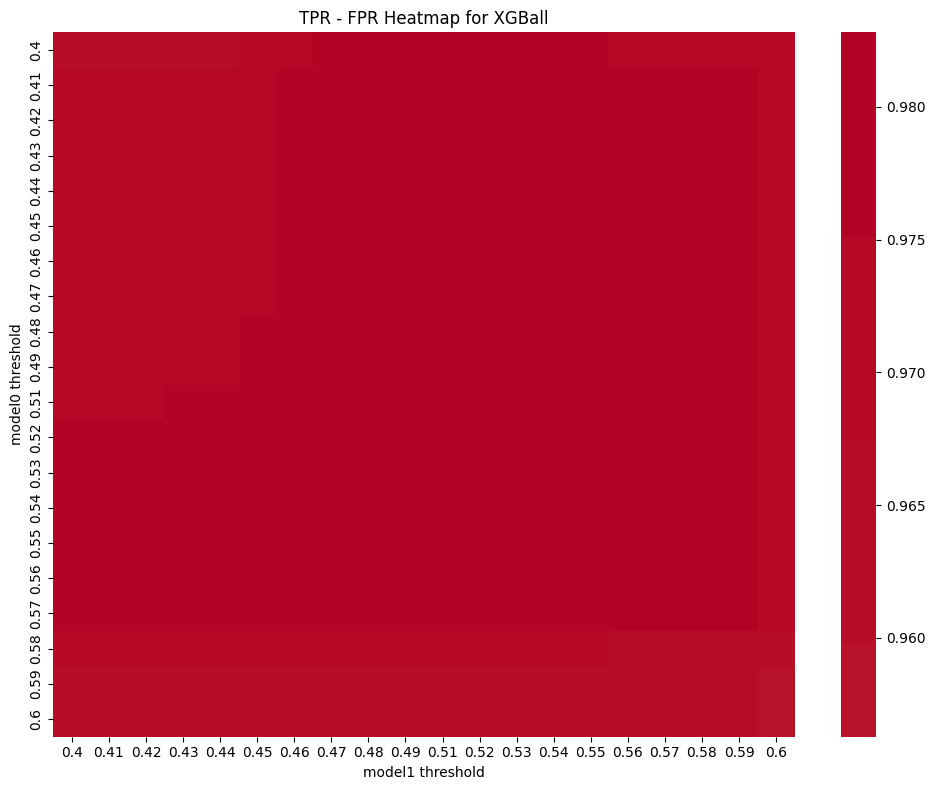

In [57]:
thresholds0 = np.linspace(0.4, 0.6, 20)
thresholds1 = np.linspace(0.4, 0.6, 20)

roc_matrix = np.zeros((len(thresholds0), len(thresholds1)))
pr_matrix = np.zeros((len(thresholds0), len(thresholds1)))

tpr_minus_fpr_matrix = np.full((len(thresholds0), len(thresholds1)), np.nan)

for i, t0 in enumerate(thresholds0):
    for j, t1 in enumerate(thresholds1):
        pred_comb = ((prob0 > t0) & (prob1 > t1)).astype(int)

        if len(np.unique(pred_comb)) < 2:
            continue

        tn, fp, fn, tp = confusion_matrix(y_true, pred_comb).ravel()

        tpr = tp / (tp + fn) if (tp + fn) != 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) != 0 else 0

        tpr_minus_fpr_matrix[i, j] = tpr - fpr
        
plt.figure(figsize=(10, 8))
sns.heatmap(tpr_minus_fpr_matrix, xticklabels=np.round(thresholds1, 2), yticklabels=np.round(thresholds0, 2), cmap='coolwarm', center=0)
plt.title("TPR - FPR Heatmap for XGBall")
plt.xlabel("model1 threshold")
plt.ylabel("model0 threshold")
plt.tight_layout()
plt.show()

In [59]:
tpr_fpr_df = pd.DataFrame(tpr_minus_fpr_matrix, index=np.round(thresholds0, 2), columns=np.round(thresholds1, 2))
tpr_fpr_df.index.name = 'model0 threshold'
tpr_fpr_df.columns.name = 'model1 threshold'
# 获取桌面路径（Windows）
desktop = os.path.join(os.path.expanduser("~"), "Desktop")
tpr_fpr_path = os.path.join(desktop, "ensemble_roc.xlsx")
tpr_fpr_df.to_excel(tpr_fpr_path)

print(f"TPR - FPR 热图数据已保存到桌面：\n{tpr_fpr_path}")

TPR - FPR 热图数据已保存到桌面：
C:\Users\hp\Desktop\ensemble_roc.xlsx


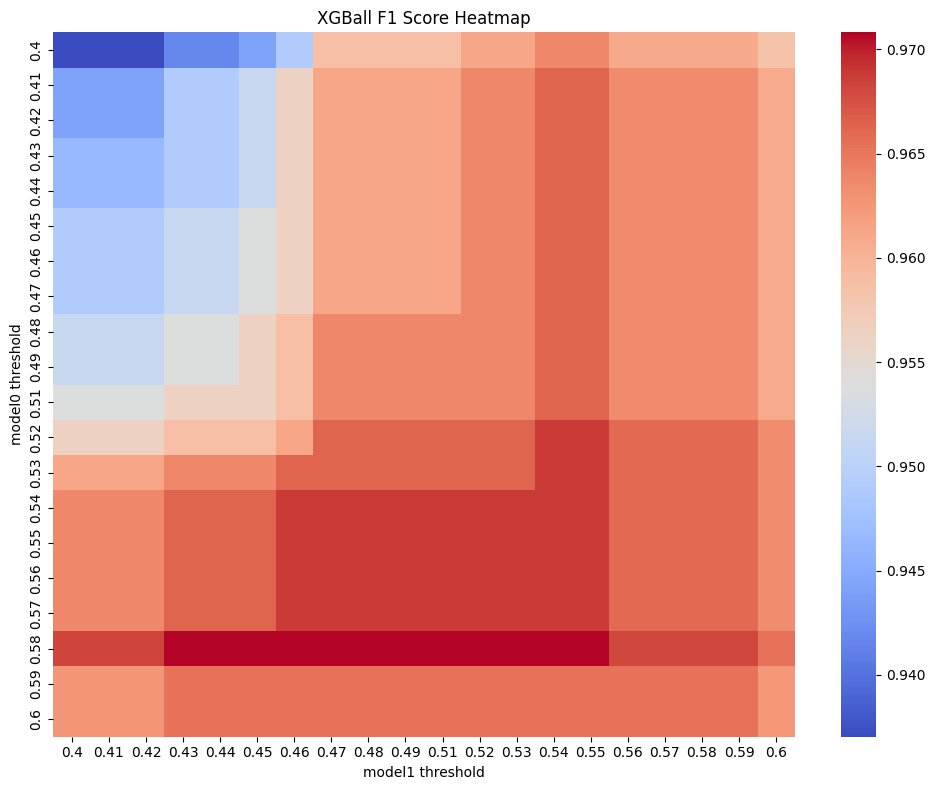

F1 得分矩阵已保存到桌面：
C:\Users\hp\Desktop\ensemble_pr.xlsx


In [61]:
from sklearn.metrics import f1_score

f1_matrix = np.zeros((len(thresholds0), len(thresholds1)))

for i, t0 in enumerate(thresholds0):
    for j, t1 in enumerate(thresholds1):
        pred_comb = ((prob0 > t0) & (prob1 > t1)).astype(int)
        if len(np.unique(pred_comb)) < 2:  
            f1_matrix[i, j] = np.nan
        else:
            f1_matrix[i, j] = f1_score(y_true, pred_comb)
plt.figure(figsize=(10, 8))
sns.heatmap(f1_matrix, xticklabels=np.round(thresholds1, 2), yticklabels=np.round(thresholds0, 2), cmap='coolwarm')
plt.title("XGBall F1 Score Heatmap")
plt.xlabel("model1 threshold")
plt.ylabel("model0 threshold")
plt.tight_layout()
plt.show()
f1_df = pd.DataFrame(f1_matrix, index=np.round(thresholds0, 2), columns=np.round(thresholds1, 2))
f1_df.index.name = 'model0 threshold'
f1_df.columns.name = 'model1 threshold'

desktop = os.path.join(os.path.expanduser("~"), "Desktop")
f1_path = os.path.join(desktop, "ensemble_pr.xlsx")

f1_df.to_excel(f1_path)

print(f"F1 得分矩阵已保存到桌面：\n{f1_path}")

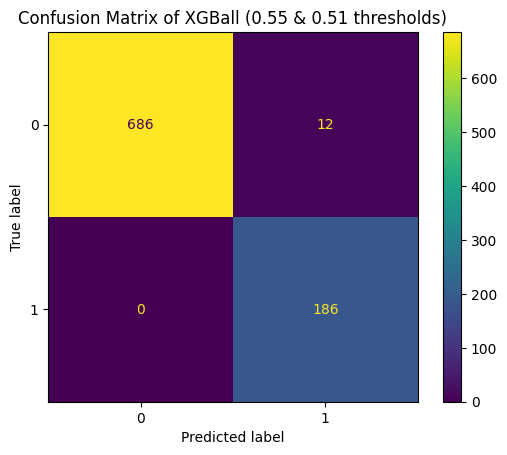

In [63]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, average_precision_score
import seaborn as sns
import matplotlib.pyplot as plt


y_true = data_train_d.iloc[:, -1].values  # 假设两个data的最后一列都是label，且一样


prob0 = model0.predict(xgb.DMatrix(x_standard1))  # model0 on data_train_d
prob1 = model1.predict(xgb.DMatrix(x_standard2))  # model1 on data_train_f

xgball_pred = ((prob0 > 0.55) & (prob1 > 0.51)).astype(int)


cm = confusion_matrix(y_true, xgball_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix of XGBall (0.55 & 0.51 thresholds)")
plt.show()

In [76]:
o0 = pd.read_excel("output_d_all.xlsx")
o1 = pd.read_excel("output_f_all.xlsx")

In [80]:
l=0
l_f = 0
l_y = 0
oo = pd.DataFrame()
for i in range(260040):
    if o0.iloc[i,2] == o1.iloc[i,2]:
        l+=1
    if o0.iloc[i,2] == 1 and o1.iloc[i,2]==0:
        l_f+=1
    if o0.iloc[i,2] == 0 and o1.iloc[i,2]==1:
        l_f+=1
    if o0.iloc[i,2] == 1 and o1.iloc[i,2]==1:
        l_y+=1
        oo0 = pd.concat([o0.iloc[i,:],o1.iloc[i,:]],axis = 0)
        oo0 = oo0.T
        oo = pd.concat([oo,oo0],axis = 1)
oo = oo.T

In [90]:
oo.columns = ['num_d','smiles_d','predict_class_d','level_d','num_f','smiles_f','predict_class_f','level_f']

In [95]:
output = oo
k = []
for i in range(len(output.index)):
    if output.iloc[i,2]==1:
        k.append(i)
output0 = output.iloc[k,:]

In [97]:
output0.reset_index(inplace=True, drop=True)

from rdkit import rdBase
rdBase.DisableLog('rdApp.warning')
from rdkit import Chem
from rdkit.Contrib.SA_Score import sascorer
SMILES=output0['smiles_d']
SA=[]
for n,i in enumerate(SMILES):
       x_mol=Chem.MolFromSmiles(i)   # 转为mol
       SAscore=sascorer.calculateScore(x_mol)
       SA.append(SAscore)

output_final=pd.concat([output0,pd.DataFrame(SA,columns=['SA'])],axis=1)

num = len(output0.index)

ll = []
for ii in range(num):
    i = output0.iloc[ii,1]
    if '#'  in i or 'Si' in i or 'Br'  in i or 'Cl' in i or 'I'  in i or 'C(=O' in i or '=' in i or 'PH' in i or 'O'in i or 'S' in i or'NH2' in i or 'NH'in i:
        ll.append(ii)
output_final.drop(index=ll, inplace=True, axis=0)
output_final.reset_index(inplace=True, drop=True)

In [118]:
output_final

,num_d,smiles_d,predict_class_d,level_d,num_f,smiles_f,predict_class_f,level_f,SA
0,24704,C1CCN([P+](N2CCCCC2)(N2CCCCC2)N2CCCCC2)CC1,1,0.925643,24704,C1CCN([P+](N2CCCCC2)(N2CCCCC2)N2CCCCC2)CC1,1,0.955094,2.815272
1,33694,C[N+]1CCCC[C@@H]1CP(C1CCCCC1)C1CCCCC1,1,0.780984,33694,C[N+]1CCCC[C@@H]1CP(C1CCCCC1)C1CCCCC1,1,0.51124,4.043362
2,38683,C[P+](N1CCCCC1)(N1CCCCC1)N1CCCCC1,1,0.831168,38683,C[P+](N1CCCCC1)(N1CCCCC1)N1CCCCC1,1,0.8725,3.012899
3,39973,CC(C)(C)[P+](N1CCCCC1)(N1CCCCC1)N1CCCCC1,1,0.80488,39973,CC(C)(C)[P+](N1CCCCC1)(N1CCCCC1)N1CCCCC1,1,0.874806,3.109019
4,41366,CN[P+](N1CCCCC1)(N1CCCCC1)N1CCCCC1,1,0.846747,41366,CN[P+](N1CCCCC1)(N1CCCCC1)N1CCCCC1,1,0.742478,3.185094
...,...,...,...,...,...,...,...,...,...
151,46858,CCCCc1c[n+](-c2ccc(C)cc2)nn1Cc1ccc(C(C)(C)C)cc1,1,0.881166,46858,CCCCc1c[n+](-c2ccc(C)cc2)nn1Cc1ccc(C(C)(C)C)cc1,1,0.57011,2.792852
152,52977,Cc1n(CCN(C)C)cc[n+]1CCN(C)C,1,0.566169,52977,Cc1n(CCN(C)C)cc[n+]1CCN(C)C,1,0.745333,3.026912
153,60636,CCCCCCCCCCCCc1c[n+](Cc2ccccc2)nn1Cc1ccccc1,1,0.759493,60636,CCCCCCCCCCCCc1c[n+](Cc2ccccc2)nn1Cc1ccccc1,1,0.652062,2.551122
154,68256,CCCCCCCCc1c[n+](-c2ccc(C)cc2)nn1Cc1ccccc1,1,0.776071,68256,CCCCCCCCc1c[n+](-c2ccc(C)cc2)nn1Cc1ccccc1,1,0.556372,2.655702


In [103]:
output_final1 = output_final.drop_duplicates(subset=["smiles_d"])

In [122]:
last_column = output_final1.columns[-1]
filtered_df = output_final1[output_final1[last_column] < 3.5]
filtered_df.reset_index(inplace=True, drop=True)

In [126]:
filtered_df.to_excel('output_final.xlsx', index=False)

In [143]:
from rdkit.Chem import Draw
chem_folder = "molecular_photo"
smiles_list =filtered_df['smiles_d']

for i, smiles in enumerate(smiles_list):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
                              
            output_path = os.path.join(chem_folder, f"structure_{i+1}.png")
            Draw.MolToFile(mol, output_path)
            print(f"Saved: {output_path}")
        else:
            print(f"Invalid SMILES: {smiles}")
    except Exception as e:
            print(f"Error processing SMILES {smiles}: {e}")

Saved: molecular_photo\structure_1.png
Saved: molecular_photo\structure_2.png
Saved: molecular_photo\structure_3.png
Saved: molecular_photo\structure_4.png
Saved: molecular_photo\structure_5.png
Saved: molecular_photo\structure_6.png
Saved: molecular_photo\structure_7.png
Saved: molecular_photo\structure_8.png
Saved: molecular_photo\structure_9.png
Saved: molecular_photo\structure_10.png
Saved: molecular_photo\structure_11.png
Saved: molecular_photo\structure_12.png
Saved: molecular_photo\structure_13.png
Saved: molecular_photo\structure_14.png
Saved: molecular_photo\structure_15.png
Saved: molecular_photo\structure_16.png
Saved: molecular_photo\structure_17.png
Saved: molecular_photo\structure_18.png
Saved: molecular_photo\structure_19.png
Saved: molecular_photo\structure_20.png
Saved: molecular_photo\structure_21.png
Saved: molecular_photo\structure_22.png
Saved: molecular_photo\structure_23.png
Saved: molecular_photo\structure_24.png
Saved: molecular_photo\structure_25.png
Saved: mo